# 01 — Análisis Inicial de Fuentes (Perfil de Calidad)

En este notebook realizamos el análisis de calidad inicial de las 4 fuentes de datos sin aplicar ninguna transformación. Ya que nuestro objetivo en este noteebook es establecer la base que justifique las limpiezas que hagamos después.

### Fuentes analizadas
- Fuente 1: Weekly Oil Bulletin Prices (Excel) — Comisión Europea. Precios semanales del petróleo
- Fuente 2: Oil Bulletin Duties and Taxes (Excel) — Comisión Europea. Impuestos y tasas
- Fuente 3: Eurostat Energy Indicators NRG (CSV) — Eurostat. Indicadores energéticos
- Fuente 4: World Bank GDP per capita (CSV) — World Bank Open Data. PIB per cápita

In [2]:
#Importamos las librerias necesarias para para cargar datos, hacer gráficas y silenciar los avisos inncesarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Cargamos los archivos
import pandas as pd

BASE = "https://raw.githubusercontent.com/nataliablancot-cyber/Trabajo-Big-Data-/main/data/raw/"

# Fuente 1 - Weekly Oil Bulletin
df1 = pd.read_excel(BASE + "Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx", skiprows=2)

# Fuente 2 - Duties and Taxes
df2 = pd.read_excel(BASE + "Oil_Bulletin_Duties_and_taxes.xlsx")

# Fuente 3 - Eurostat
df3 = pd.read_csv(BASE + "nrg_ind_id%24defaultview_linear.csv")

# Fuente 4 - World Bank
df4 = pd.read_csv(BASE + "API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv", skiprows=4)


print("Todas las fuentes han sido cargadas correctamente")


Todas las fuentes han sido cargadas correctamente


## Fuente 1 — Weekly Oil Bulletin Prices
 Esta fuente trata sobre los precios semanales de combustibles en Europa por país y tipo de producto.
 El formato de este archivo es:
 - Una fila por semana
 - Una columna por país/producto
## Analizamos el estado inicial de la Fuente 1

In [ ]:
#Imprimimos el número de filas y COlumnas del Dataframe para saber el tamaño exacto del dataset
print("SHAPE (filas, columnas):")
print(df1.shape)


SHAPE (filas, columnas):
(1089, 226)


In [ ]:
#Mostramos el tipo de dato por cada columna
print("\nTIPOS DE DATO:")
print(df1.dtypes)


TIPOS DE DATO:
Date           object
Unnamed: 1     object
1000 l         object
1000 l.1       object
1000 l.2      float64
               ...   
1000 l.117    float64
1000 l.118    float64
t.58          float64
t.59          float64
1000 l.119    float64
Length: 226, dtype: object


In [ ]:
#Contamos cuántos valores vacíos hay en cada una de las columnas para saber qué datos faltan y así poder decididr que hacer después

print("\nNULOS POR COLUMNA (primeras 10):")
print(df1.isnull().sum().head(10))


NULOS POR COLUMNA (primeras 10):
Date          24
Unnamed: 1    12
1000 l        14
1000 l.1      19
1000 l.2      25
t             25
t.1           25
1000 l.3      25
Unnamed: 8    14
1000 l.4      15
dtype: int64


In [ ]:
#Miramos cuantas filas están repetidad en el dataset, ya que los duplicados afectan en el análisis
print("\nDUPLICADOS:")
print(df1.duplicated().sum())


DUPLICADOS:
5


In [ ]:
#Sirve para saber cuantos valores distintos hay por cada columna para poder detectar columans con poca variabilidad
print("\nVALORES ÚNICOS POR COLUMNA (primeras 10):")
print(df1.nunique().head(10))


VALORES ÚNICOS POR COLUMNA (primeras 10):
Date          1065
Unnamed: 1       9
1000 l        1075
1000 l.1      1070
1000 l.2      1064
t             1064
t.1           1064
1000 l.3      1064
Unnamed: 8       3
1000 l.4      1074
dtype: int64


In [ ]:
#Calculamos las estadísticas básicas de las columnas númericas
print("\nESTADÍSTICAS NUMÉRICAS:")
print(df1.describe())


ESTADÍSTICAS NUMÉRICAS:
          1000 l.2            t          t.1     1000 l.3     1000 l.6  \
count  1064.000000  1064.000000  1064.000000  1064.000000  1064.000000   
mean    845.097140   523.014666   410.124497   631.323263   828.346375   
std     224.269169   140.391939   128.914772   105.294388   224.346824   
min     479.719294   247.562462   134.335521   445.726205   465.512390   
25%     667.444357   398.603421   306.296779   546.358749   653.389715   
50%     804.887853   519.941970   400.098229   605.513923   774.838215   
75%     967.161696   640.258587   519.743442   710.048379   954.518907   
max    1737.682587   859.377663   742.480490   934.959553  1750.480259   

               t.2         t.3     1000 l.7     1000 l.8     1000 l.9  ...  \
count  1064.000000  555.000000  1064.000000  1062.000000  1062.000000  ...   
mean    488.579525  448.746285   693.821344  1294.094162  1262.753296  ...   
std     139.263485  100.561817   104.057847   208.972741   256.163917  ...

### Interpretación Fuente 1 — Weekly Oil Bulletin

Gracias a estas operaciones hemos podido observar que:

- **Shape:** 1089 filas × 226 columnas. Formato: cada semana es una fila y cada columna es un país/producto combinado.

- **Tipos de dato:** Podemos ver que la columna Date está almacenada como texto y debería estar como fecha (datetime), por lo que su conversión va a ser necesaria. El resto de columnas tienen el tipo de datos correcto.

- **Nulos:** En varias columnas aparecen valores nulos, especialmente en los productos menos comunes como fuel oil. Esto es algo normal ya que no todos los países recogen los mismos productos.

- **Duplicados:** Hay 5 filas duplicadas que tendremos que eliminar en la fase ETL.

- **Nombres de columnas:** Los nombres de las columnas son muy poco descriptivos (por ejemplo: 1000 l), por lo que será necesario renombrarlos en la fase ETL.

- **Análisis estadístico:** Los precios medios están alrededor de 800-1300€ por 1000 litros según el tipo de combustible y el país. El precio mínimo es 134€ y el precio máximo es 2402€. Esta diferencia muestra la gran variación de los precios a lo largo del tiempo y entre países.

## Fuente 2 — Oil Bulletin Duties and Taxes
Impuestos y tasas aplicados a los combustibles por país.
Contiene varias hojas: VAT, Excise duties y Other Indirect Taxes.
##Analizamos el estado inicial de la Fuente 2

Analizamos las 3 hojas del archivo de forma individual. Pero, para evitar repetir
el mismo código 3 veces, usamos un bucle (for) que aplica el mismo análisis
a cada hoja automáticamente.

In [4]:
#Fuente 2: DUTIES AND TAXES

import io, requests
response = requests.get(BASE + "Oil_Bulletin_Duties_and_taxes.xlsx")
xl = pd.ExcelFile(io.BytesIO(response.content))

#Imprimimos los nombres de todas las hojas del archivo
print("HOJAS DEL ARCHIVO:")
print(xl.sheet_names)

#Aquí se recorre cada hoja una por una, y nos imprime el nombre.
for hoja in xl.sheet_names:
    print(f'\n{"="*60}')
    print(f'  HOJA: {hoja}')
    print(f'{"="*60}')

    df_hoja = xl.parse(hoja)

    print("\nSHAPE (filas, columnas):")
    print(df_hoja.shape)

    print("\nTIPOS DE DATO:")
    print(df_hoja.dtypes)

    print("\nNULOS POR COLUMNA:")
    print(df_hoja.isnull().sum())

    print("\nDUPLICADOS:")
    print(df_hoja.duplicated().sum())

    print("\nVALORES ÚNICOS POR COLUMNA:")
    print(df_hoja.nunique())

    print("\nESTADÍSTICAS NUMÉRICAS:")
    print(df_hoja.describe())

    print("\nBLANCOS EN COLUMNAS DE TEXTO:")
    for col in df_hoja.select_dtypes('object').columns:
        blancos = (df_hoja[col].astype(str).str.strip() == '').sum()
        print(f'  {col}: {blancos} blancos')

HOJAS DEL ARCHIVO:
['VAT', 'Excise duties', 'Other Indirect Taxes']

  HOJA: VAT

SHAPE (filas, columnas):
(35, 8)

TIPOS DE DATO:
Unnamed: 0                  object
Unnamed: 1                  object
VAT (Value added tax), %    object
Unnamed: 3                  object
Unnamed: 4                  object
Unnamed: 5                  object
Unnamed: 6                  object
Unnamed: 7                  object
dtype: object

NULOS POR COLUMNA:
Unnamed: 0                   7
Unnamed: 1                   6
VAT (Value added tax), %     6
Unnamed: 3                   6
Unnamed: 4                   6
Unnamed: 5                  10
Unnamed: 6                  25
Unnamed: 7                  13
dtype: int64

DUPLICADOS:
3

VALORES ÚNICOS POR COLUMNA:
Unnamed: 0                  28
Unnamed: 1                  26
VAT (Value added tax), %    15
Unnamed: 3                  15
Unnamed: 4                  15
Unnamed: 5                  15
Unnamed: 6                   7
Unnamed: 7                  11
dt

### Interpretación Fuente 2 — Duties and Taxes
Gracias a estas operaciones hemos podido observar que:

* **Shape:** Las 3 hojas tienen la misma estructura: 35 filas × 8 columnas.
  Cada fila representa un país y cada columna un tipo de combustible o periodo temporal.

* **Tipos de dato:** Todas las columnas de las 3 hojas son texto (object),
  incluyendo los valores numéricos de los impuestos, por lo que su conversión a números decimales (float) es necesaria en la etapa ETL.
* **Nulos:**
    - Hoja VAT: La columna Unnamed: 6 tiene 25 valores vacíos, por lo que es la columna con más valores nulos, ya que, la columna Unnamed: 5 tiene 10 nulos y la columna  Unnamed: 7 tiene 13 nulos.
    
    - Hoja Excise duties: Unnamed: 6 tiene 22 nulos y Unnamed: 5 tiene 11 nulos.
    
    - Hoja Other Indirect Taxes: Unnamed: 6 tiene 26 nulos y esta es la columna con más valores nulos de las 3 hojas

* **Duplicados:** Las 3 hojas tienen 3 filas duplicadas cada una. Las cuales tienen que ser eliminadas en la fase ETL

* **Nombres de columnas:** Los nombres son poco descriptivos (Unnamed: 0,
  Unnamed: 1...), por lo tanto será necesario cambiarlo en la etapa ETL

* **Análisis estadístico:**
   - Hoja VAT: El IVA más frecuente entre los países de UE es el del valor 21% y en total hay 15 valores diferentes de IVA.

  - Hoja Excise duties: Hay 29 valores diferentes de los impuestos fijos que cada gobierno aplica directamente sobre los combustibles.

  - Hoja Other Indirect Taxes:La mayoría de los países no aplican un impuesto indirecto adicional a los combustibles. Ya que la mayoría de los países tienen un valor 0.

* **Blancos:** No hay celdas con espacios en blanco en ninguna de las 3 hojas.


## Fuente 3 — Eurostat Energy Indicators (NRG)
Indicadores de dependencia energética por país y año.
Formato largo: cada fila representa un país y año concreto, en vez de tener una columna por cada año

In [23]:
print("SHAPE (filas, columnas):")
print(df3.shape)

SHAPE (filas, columnas):
(409, 10)


In [8]:
print("\nTIPOS DE DATO:")
print(df3.dtypes)


TIPOS DE DATO:
DATAFLOW        object
LAST UPDATE     object
freq            object
siec            object
unit            object
geo             object
TIME_PERIOD      int64
OBS_VALUE      float64
OBS_FLAG       float64
CONF_STATUS    float64
dtype: object


In [9]:
print("\nNULOS POR COLUMNA:")
print(df3.isnull().sum())


NULOS POR COLUMNA:
DATAFLOW         0
LAST UPDATE      0
freq             0
siec             0
unit             0
geo              0
TIME_PERIOD      0
OBS_VALUE        0
OBS_FLAG       409
CONF_STATUS    409
dtype: int64


In [10]:
print("\nDUPLICADOS:")
print(df3.duplicated().sum())


DUPLICADOS:
0


In [11]:
print("\nVALORES ÚNICOS POR COLUMNA:")
print(df3.nunique())


VALORES ÚNICOS POR COLUMNA:
DATAFLOW         1
LAST UPDATE      1
freq             1
siec             1
unit             1
geo             42
TIME_PERIOD     10
OBS_VALUE      409
OBS_FLAG         0
CONF_STATUS      0
dtype: int64


In [12]:
print("\nESTADÍSTICAS NUMÉRICAS:")
print(df3.describe())


ESTADÍSTICAS NUMÉRICAS:
       TIME_PERIOD   OBS_VALUE  OBS_FLAG  CONF_STATUS
count   409.000000  409.000000       0.0          0.0
mean   2019.420538   37.466066       NaN          NaN
std       2.864449  107.566159       NaN          NaN
min    2015.000000 -682.103000       NaN          NaN
25%    2017.000000   34.031000       NaN          NaN
50%    2019.000000   54.121000       NaN          NaN
75%    2022.000000   72.241000       NaN          NaN
max    2024.000000  103.052000       NaN          NaN


In [13]:
print("\nBLANCOS EN COLUMNAS DE TEXTO:")
for col in df3.select_dtypes('object').columns:
    blancos = (df3[col].astype(str).str.strip() == '').sum()
    print(f'{col}: {blancos} blancos')



BLANCOS EN COLUMNAS DE TEXTO:
DATAFLOW: 0 blancos
LAST UPDATE: 0 blancos
freq: 0 blancos
siec: 0 blancos
unit: 0 blancos
geo: 0 blancos


In [14]:
#Mostramos las 5 primeras filas del dataset para ver como esta estructurado
print("\nPRIMERAS FILAS:")
print(df3.head())


PRIMERAS FILAS:
                            DATAFLOW        LAST UPDATE    freq   siec  \
0  ESTAT:NRG_IND_ID$DEFAULTVIEW(1.0)  21/04/26 23:00:00  Annual  Total   
1  ESTAT:NRG_IND_ID$DEFAULTVIEW(1.0)  21/04/26 23:00:00  Annual  Total   
2  ESTAT:NRG_IND_ID$DEFAULTVIEW(1.0)  21/04/26 23:00:00  Annual  Total   
3  ESTAT:NRG_IND_ID$DEFAULTVIEW(1.0)  21/04/26 23:00:00  Annual  Total   
4  ESTAT:NRG_IND_ID$DEFAULTVIEW(1.0)  21/04/26 23:00:00  Annual  Total   

         unit      geo  TIME_PERIOD  OBS_VALUE  OBS_FLAG  CONF_STATUS  
0  Percentage  Albania         2015     12.593       NaN          NaN  
1  Percentage  Albania         2016     20.128       NaN          NaN  
2  Percentage  Albania         2017     38.126       NaN          NaN  
3  Percentage  Albania         2018     20.967       NaN          NaN  
4  Percentage  Albania         2019     31.546       NaN          NaN  


### Interpretación Fuente 3 — Eurostat
Gracias a estas operaciones hemos podido observar que:

* **Shape:** 409 filas × 10 columnas. Los datos están organizados de forma que cada fila representa un país y un año concreto, en lugar de tener una columna por cada año.

* **Tipos de dato:** La columna TIME_PERIOD aparece como número entero (int64), correcto para años. OBS_VALUE aparece como decimal, también correcto ya que son porcentajes. Sin embargo, las columnas OBS_FLAG y CONF_STATUS aparecen como decimal pero están completamente vacías, por lo que se eliminarán en ETL. El resto de columnas aparecen como texto, lo cual está bien.

* **Nulos:** Las columnas OBS_FLAG y CONF_STATUS están totalmente vacías con 409 valores vacíos cada una. Se eliminarán en ETL ya que no aportan información.

* **Duplicados:** No hay filas duplicadas.

* **Valores únicos:** Hay 42 países distintos y 10 años diferentes (2015-2024). Las columnas DATAFLOW, LAST UPDATE, freq, siec y unit tienen un único valor cada una, por lo que tampoco aportan información útil y se podrán eliminar en ETL.

* **Blancos:** No hay celdas con espacios en blanco en ninguna columna.

* **Análisis estadístico:** Los valores de dependencia energética tienen una media de 37%, con un mínimo de -682% y un máximo de 103%. El valor negativo mínimo indica que algunos países exportan más energía de la que importan. Los datos cubren el periodo 2015-2024.

## Fuente 4 — World Bank GDP per capita
PIB per cápita en dólares por país y año.
Formato ancho: una fila por país, una columna por año (1960-2024).

In [24]:
print("SHAPE (filas, columnas):")
print(df4.shape)


SHAPE (filas, columnas):
(266, 71)


In [15]:
print("\nTIPOS DE DATO:")
print(df4.dtypes)


TIPOS DE DATO:
Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
1960              float64
                   ...   
2022              float64
2023              float64
2024              float64
2025              float64
Unnamed: 70       float64
Length: 71, dtype: object


In [16]:
print("\nNULOS POR COLUMNA (primeras 10):")
print(df4.isnull().sum().head(10))


NULOS POR COLUMNA (primeras 10):
Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              115
1961              112
1962              110
1963              110
1964              110
1965              104
dtype: int64


In [17]:
print("\nTOTAL NULOS:")
print(df4.isnull().sum().sum())


TOTAL NULOS:
3261


In [18]:
print("\nDUPLICADOS:")
print(df4.duplicated().sum())


DUPLICADOS:
0


In [19]:
print("\nVALORES ÚNICOS POR COLUMNA (primeras 5):")
print(df4.nunique().head(5))


VALORES ÚNICOS POR COLUMNA (primeras 5):
Country Name      266
Country Code      266
Indicator Name      1
Indicator Code      1
1960              149
dtype: int64


In [20]:
print("\nESTADÍSTICAS NUMÉRICAS (últimos 5 años):")
print(df4[['2020','2021','2022','2023','2024']].describe())


ESTADÍSTICAS NUMÉRICAS (últimos 5 años):
                2020           2021           2022           2023  \
count     258.000000     258.000000     257.000000     251.000000   
mean    16283.153813   18803.437185   19476.548373   20172.185789   
std     24311.651161   28779.971299   28996.961493   30917.462749   
min       255.832454     264.980379     302.992505     250.627253   
25%      2133.015667    2462.698252    2536.400502    2541.703814   
50%      6131.818702    7001.419123    7606.237525    7802.824333   
75%     19908.734345   22009.595072   24387.038729   23979.291930   
max    176891.886538  223823.363960  226052.001905  256799.788613   

                2024  
count     240.000000  
mean    19724.631062  
std     30040.258015  
min       219.424831  
25%      2619.263802  
50%      7836.504782  
75%     24745.502555  
max    288001.433369  


In [21]:
print("\nBLANCOS EN COLUMNAS DE TEXTO:")
for col in df4.select_dtypes('object').columns:
    blancos = (df4[col].astype(str).str.strip() == '').sum()
    print(f'{col}: {blancos} blancos')


BLANCOS EN COLUMNAS DE TEXTO:
Country Name: 0 blancos
Country Code: 0 blancos
Indicator Name: 0 blancos
Indicator Code: 0 blancos


In [22]:
print("\nPRIMERAS FILAS:")
print(df4.head())


PRIMERAS FILAS:
                  Country Name Country Code                Indicator Name  \
0                        Aruba          ABW  GDP per capita (current US$)   
1  Africa Eastern and Southern          AFE  GDP per capita (current US$)   
2                  Afghanistan          AFG  GDP per capita (current US$)   
3   Africa Western and Central          AFW  GDP per capita (current US$)   
4                       Angola          AGO  GDP per capita (current US$)   

   Indicator Code        1960        1961        1962        1963        1964  \
0  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   
1  NY.GDP.PCAP.CD  186.089204  186.909053  197.367547  225.400079  208.962717   
2  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   
3  NY.GDP.PCAP.CD  121.936832  127.451040  133.823783  139.004980  148.545883   
4  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   

         1965  ...          2017 

### Interpretación Fuente 4 — World Bank GDP per capita
Gracias a estas operaciones hemos podido observar que:

* **Shape:** 266 filas × 71 columnas. Cada fila representa un país y cada columna un año desde 1960 hasta 2024.

* **Tipos de dato:** Las 4 primeras columnas (Country Name, Country Code, Indicator Name, Indicator Code) aparecen como texto, por lo que está bien. El resto de columnas también están bien ya que aparecen como decimal (float), correcto para valores de PIB.

* **Nulos:** En total hay 3261 valores vacíos. Los valores nulos van disminuyendo a medida que nos acercamos hacia años más recientes. El año con más valores vacíos es 1960 con 115 nulos, ya que muchos países no tenían sistemas de medición del PIB.

* **Duplicados:** No hay filas duplicadas.

* **Valores únicos:** Hay 266 países distintos y cada uno tiene un nombre y código únicos. Las columnas Indicator Name e Indicator Code tienen el mismo valor en todas las filas, por lo que no aportan información útil y pueden ser eliminadas en ETL.

* **Blancos:** No hay celdas con espacios en blanco en ninguna columna de texto.

* **Análisis estadístico:** El PIB per cápita medio en 2024 es de 19.724 USD, con un mínimo de 219 USD y un máximo de 288.001 USD. Esta gran diferencia entre el mínimo y el máximo muestra una enorme desigualdad económica entre países. La desviación típica es muy alta (30.040 USD), lo que confirma que los datos están muy dispersos.

## Análisis de Rangos y Formatos de Campo
Verificamos si hay fechas mal formateadas, valores fuera de rango o problemas de formato en las columnas clave de cada fuente.

In [54]:
# RANGOS Y FORMATOS DE CAMPO

# Fuente 1 - Verificamos formato de fechas
print("=== F1 — Weekly Oil Bulletin ===")
print("Muestra de valores de la columna Date:")
print(df1['Date'].dropna().head(5).values)
print(f"Valores no nulos en Date: {df1['Date'].notna().sum()}")

# Fuente 3 - Verificamos rango de años
print("\n=== F3 — Eurostat ===")
print(f"Rango de años (TIME_PERIOD): {df3['TIME_PERIOD'].min()} - {df3['TIME_PERIOD'].max()}")
print(f"Valores negativos en OBS_VALUE: {(df3['OBS_VALUE'] < 0).sum()}")

# Fuente 4 - Verificamos rango de PIB
print("\n=== F4 — World Bank ===")
print(f"Rango PIB 2024: {df4['2024'].min():.2f} - {df4['2024'].max():.2f}")
print(f"Valores negativos en PIB 2024: {(df4['2024'] < 0).sum()}")

# Fuente 2 - Verificamos formato de fechas en Duties and Taxes
print("\n=== F2 — Duties and Taxes ===")
import io, requests
response = requests.get(BASE + "Oil_Bulletin_Duties_and_taxes.xlsx")
xl2 = pd.ExcelFile(io.BytesIO(response.content))
df2_vat = xl2.parse('VAT')
print("Muestra de valores de Unnamed: 1 (fechas):")
print(df2_vat['Unnamed: 1'].dropna().head(5).values)

=== F1 — Weekly Oil Bulletin ===
Muestra de valores de la columna Date:
[datetime.datetime(2026, 4, 27, 0, 0) datetime.datetime(2026, 4, 20, 0, 0)
 datetime.datetime(2026, 4, 13, 0, 0) datetime.datetime(2026, 4, 6, 0, 0)
 datetime.datetime(2026, 3, 30, 0, 0)]
Valores no nulos en Date: 1065

=== F3 — Eurostat ===
Rango de años (TIME_PERIOD): 2015 - 2024
Valores negativos en OBS_VALUE: 10

=== F4 — World Bank ===
Rango PIB 2024: 219.42 - 288001.43
Valores negativos en PIB 2024: 0

=== F2 — Duties and Taxes ===
Muestra de valores de Unnamed: 1 (fechas):
['Since:' datetime.datetime(1995, 1, 1, 0, 0)
 datetime.datetime(1996, 1, 1, 0, 0) datetime.datetime(1999, 1, 1, 0, 0)
 datetime.datetime(2014, 1, 13, 0, 0)]


### Interpretación — Rangos y Formatos de Campo

* **F1 — Weekly Oil Bulletin:** La columna Date contiene fechas correctamente formateadas en formato datetime (YYYY-MM-DD), con 1065 valores no nulos. Aunque en el análisis de tipos de dato aparecía como texto (object), los valores reales sí tienen formato de fecha correcto, por lo que no es necesario modificarla.

* **F2 — Duties and Taxes:** La columna de fechas (Unnamed: 1) contiene un valor de texto "Since:" mezclado con fechas en formato datetime. Esto confirma el problema de formato mencionado anteriormente, por lo que será necesario limpiarlo en la fase ETL.

* **F3 — Eurostat:** El rango de años es correcto (2015-2024). Los 10 valores negativos en OBS_VALUE se analizarán en la detección de outliers para determinar si son errores o valores reales.

* **F4 — World Bank:** El rango del PIB per cápita en 2024 va de 219.42 USD a 288.001 USD sin valores negativos, confirmando que no hay errores de formato en los valores económicos.

## Consistencia Referencial entre Fuentes
Verificamos si los códigos de país de las fuentes coinciden entre sí.

In [53]:
# CONSISTENCIA REFERENCIAL

# Extraemos los países de cada fuente
paises_eurostat = df3[['geo']].drop_duplicates().rename(columns={'geo': 'pais'})
paises_worldbank = df4[['Country Name']].drop_duplicates().rename(columns={'Country Name': 'pais'})

# Merge con indicator=True para ver qué países están en cada fuente
merge = pd.merge(paises_eurostat, paises_worldbank, on='pais', how='outer', indicator=True)

# Resultados
solo_eurostat = merge[merge['_merge'] == 'left_only']
solo_worldbank = merge[merge['_merge'] == 'right_only']
en_comun = merge[merge['_merge'] == 'both']

print(f"Países en Eurostat pero NO en World Bank: {len(solo_eurostat)}")
print(solo_eurostat['pais'].values)

print(f"\nPaíses en World Bank pero NO en Eurostat: {len(solo_worldbank)}")

print(f"\nPaíses en común: {len(en_comun)}")
print(en_comun['pais'].values)

Países en Eurostat pero NO en World Bank: 5
['Euro area – 20 countries (2023-2025)'
 'European Union - 27 countries (from 2020)' 'Kosovo*' 'Slovakia'
 'Türkiye']

Países en World Bank pero NO en Eurostat: 229

Países en común: 37
['Albania' 'Austria' 'Belgium' 'Bosnia and Herzegovina' 'Bulgaria'
 'Croatia' 'Cyprus' 'Czechia' 'Denmark' 'Estonia' 'Finland' 'France'
 'Georgia' 'Germany' 'Greece' 'Hungary' 'Iceland' 'Ireland' 'Italy'
 'Latvia' 'Lithuania' 'Luxembourg' 'Malta' 'Moldova' 'Montenegro'
 'Netherlands' 'North Macedonia' 'Norway' 'Poland' 'Portugal' 'Romania'
 'Serbia' 'Slovenia' 'Spain' 'Sweden' 'Ukraine' 'United Kingdom']


### Interpretación — Consistencia Referencial

* **Países en común:** 37 países aparecen en ambas fuentes (Eurostat y World Bank),
  lo que nos permite cruzar datos de dependencia energética con PIB per cápita
  para esos países.

* **Países solo en Eurostat (5):** Hay 5 entradas en Eurostat que no tienen
  correspondencia en World Bank. Destacan agregados grupos como
  "Euro area – 20 countries" y "European Union - 27 countries". Y en cuanto a países individuales, Kosovo y Türkiye tampoco aparecen en World Bank
  con ese nombre exacto.

* **Países solo en World Bank (229):** El World Bank tiene muchos más países
  que Eurostat porque Eurostat se centra en Europa. Y estos países no tienen
  datos de dependencia energética europea.

* **Conclusión:** La consistencia referencial es parcial. Para cruzar ambas fuentes
  en el modelo dimensional usaremos los 37 países en común.

* **Fuentes F1 y F2:** No es posible hacer una comparación directa de países
  con F3 y F4 porque F1 y F2 usan códigos de país abreviados (AT_, BE_, ES_...)
  en lugar de nombres completos. Esta normalización se realizará en la fase ETL,
  donde se estandarizarán los códigos de país para poder cruzar todas las fuentes.

## Detección de Outliers — Método IQR
Se consideran outliers los valores que están por debajo de Q1 - 1.5*IQR
o por encima de Q3 + 1.5*IQR.

In [47]:
# DETECCIÓN DE OUTLIERS POR IQR

def contar_outliers(df, nombre):
    print(f'\n--- {nombre} ---')
    numericas = df.select_dtypes(include='number').columns
    total = 0
    for col in numericas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
        if outliers > 0:
            print(f'  {col}: {outliers} outliers')
        total += outliers
    print(f'  TOTAL OUTLIERS: {total}')


In [48]:
contar_outliers(df1, 'Fuente 1 — Weekly Oil Bulletin')


--- Fuente 1 — Weekly Oil Bulletin ---
  1000 l.2: 36 outliers
  1000 l.6: 32 outliers
  t.3: 4 outliers
  1000 l.8: 13 outliers
  1000 l.9: 26 outliers
  1000 l.10: 36 outliers
  1000 l.12: 6 outliers
  1000 l.13: 14 outliers
  1000 l.14: 23 outliers
  t.6: 1 outliers
  1000 l.15: 10 outliers
  Unnamed: 30: 114 outliers
  1000 l.16: 6 outliers
  1000 l.17: 9 outliers
  1000 l.18: 34 outliers
  t.9: 1 outliers
  1000 l.19: 12 outliers
  Unnamed: 38: 147 outliers
  1000 l.20: 3 outliers
  1000 l.21: 5 outliers
  1000 l.22: 16 outliers
  t.10: 23 outliers
  t.11: 12 outliers
  1000 l.24: 9 outliers
  1000 l.25: 14 outliers
  1000 l.26: 37 outliers
  1000 l.27: 8 outliers
  1000 l.28: 11 outliers
  1000 l.29: 30 outliers
  1000 l.30: 32 outliers
  t.14: 11 outliers
  1000 l.31: 18 outliers
  1000 l.32: 19 outliers
  1000 l.33: 34 outliers
  1000 l.34: 17 outliers
  1000 l.36: 11 outliers
  1000 l.37: 22 outliers
  1000 l.38: 13 outliers
  1000 l.40: 10 outliers
  1000 l.41: 27 outliers
 

In [41]:
contar_outliers(df2, 'Fuente 2 — Duties and Taxes')


--- Fuente 2 — Duties and Taxes ---
  TOTAL OUTLIERS: 0


In [42]:
contar_outliers(df3, 'Fuente 3 — Eurostat NRG')


--- Fuente 3 — Eurostat NRG ---
  OBS_VALUE: 10 outliers
  TOTAL OUTLIERS: 10


In [43]:
contar_outliers(df4, 'Fuente 4 — World Bank GDP')


--- Fuente 4 — World Bank GDP ---
  1960: 23 outliers
  1961: 23 outliers
  1962: 24 outliers
  1963: 24 outliers
  1964: 24 outliers
  1965: 17 outliers
  1966: 18 outliers
  1967: 24 outliers
  1968: 27 outliers
  1969: 27 outliers
  1970: 15 outliers
  1971: 19 outliers
  1972: 21 outliers
  1973: 17 outliers
  1974: 21 outliers
  1975: 24 outliers
  1976: 24 outliers
  1977: 25 outliers
  1978: 26 outliers
  1979: 24 outliers
  1980: 26 outliers
  1981: 19 outliers
  1982: 21 outliers
  1983: 23 outliers
  1984: 21 outliers
  1985: 20 outliers
  1986: 24 outliers
  1987: 33 outliers
  1988: 34 outliers
  1989: 32 outliers
  1990: 33 outliers
  1991: 32 outliers
  1992: 37 outliers
  1993: 33 outliers
  1994: 35 outliers
  1995: 40 outliers
  1996: 41 outliers
  1997: 37 outliers
  1998: 36 outliers
  1999: 41 outliers
  2000: 40 outliers
  2001: 28 outliers
  2002: 27 outliers
  2003: 31 outliers
  2004: 33 outliers
  2005: 31 outliers
  2006: 27 outliers
  2007: 28 outliers
  200

### Interpretación — Detección de Outliers por IQR

Los outliers son valores extremos que se alejan mucho del resto de datos.
Para detectarlos usamos el método IQR: cualquier valor que esté por debajo
de Q1 - 1.5×IQR o por encima de Q3 + 1.5×IQR se considera un outlier.

- **Fuente 1 — Weekly Oil Bulletin: 2782 outliers**
  Es la fuente con más outliers. Hay periodos de precios muy altos o muy bajos, debido a eventos históricos como:
  - La crisis financiera en 2008
  - El COVID-19 en 2020
  - La Guerra de Ucrania en 2022

  Estos no son errores, son valores reales que reflejan la variabilidad en el mercado
  del petróleo.

- **Fuente 2 — Duties and Taxes: 0 outliers**
  No hay outliers debido a que los impuestos son fijados por los gobiernos y cambian
  de forma gradual, sin variaciones bruscas.

- **Fuente 3 — Eurostat NRG: 10 outliers**
  Los outliers se encuentran en la columna OBS_VALUE. El valor mínimo de -682
  indica que algunos países exportan más energía de la que importan,
  lo que genera valores negativos extremos.

- **Fuente 4 — World Bank GDP: 1708 outliers**
  Los outliers aparecen en todos los años y corresponden a países con PIB
  per cápita muy alto (como Luxemburgo o Noruega) o muy bajo. Estos no son errores, sino datos reales que reflejan la desigualdad económica mundial.

## Visualizaciones del Análisis Inicial

##GRÁFICOS DE BARRAS DE NULOS POR CADA FUENTE

[Text(0, 0, 'Unnamed: 70'),
 Text(1, 0, '2025'),
 Text(2, 0, '1960'),
 Text(3, 0, '1961'),
 Text(4, 0, '1962'),
 Text(5, 0, '1963'),
 Text(6, 0, '1964'),
 Text(7, 0, '1965'),
 Text(8, 0, '1966'),
 Text(9, 0, '1967'),
 Text(10, 0, '1968'),
 Text(11, 0, '1969'),
 Text(12, 0, '1970'),
 Text(13, 0, '1971'),
 Text(14, 0, '1972'),
 Text(15, 0, '1973'),
 Text(16, 0, '1974'),
 Text(17, 0, '1975'),
 Text(18, 0, '1976'),
 Text(19, 0, '1978')]

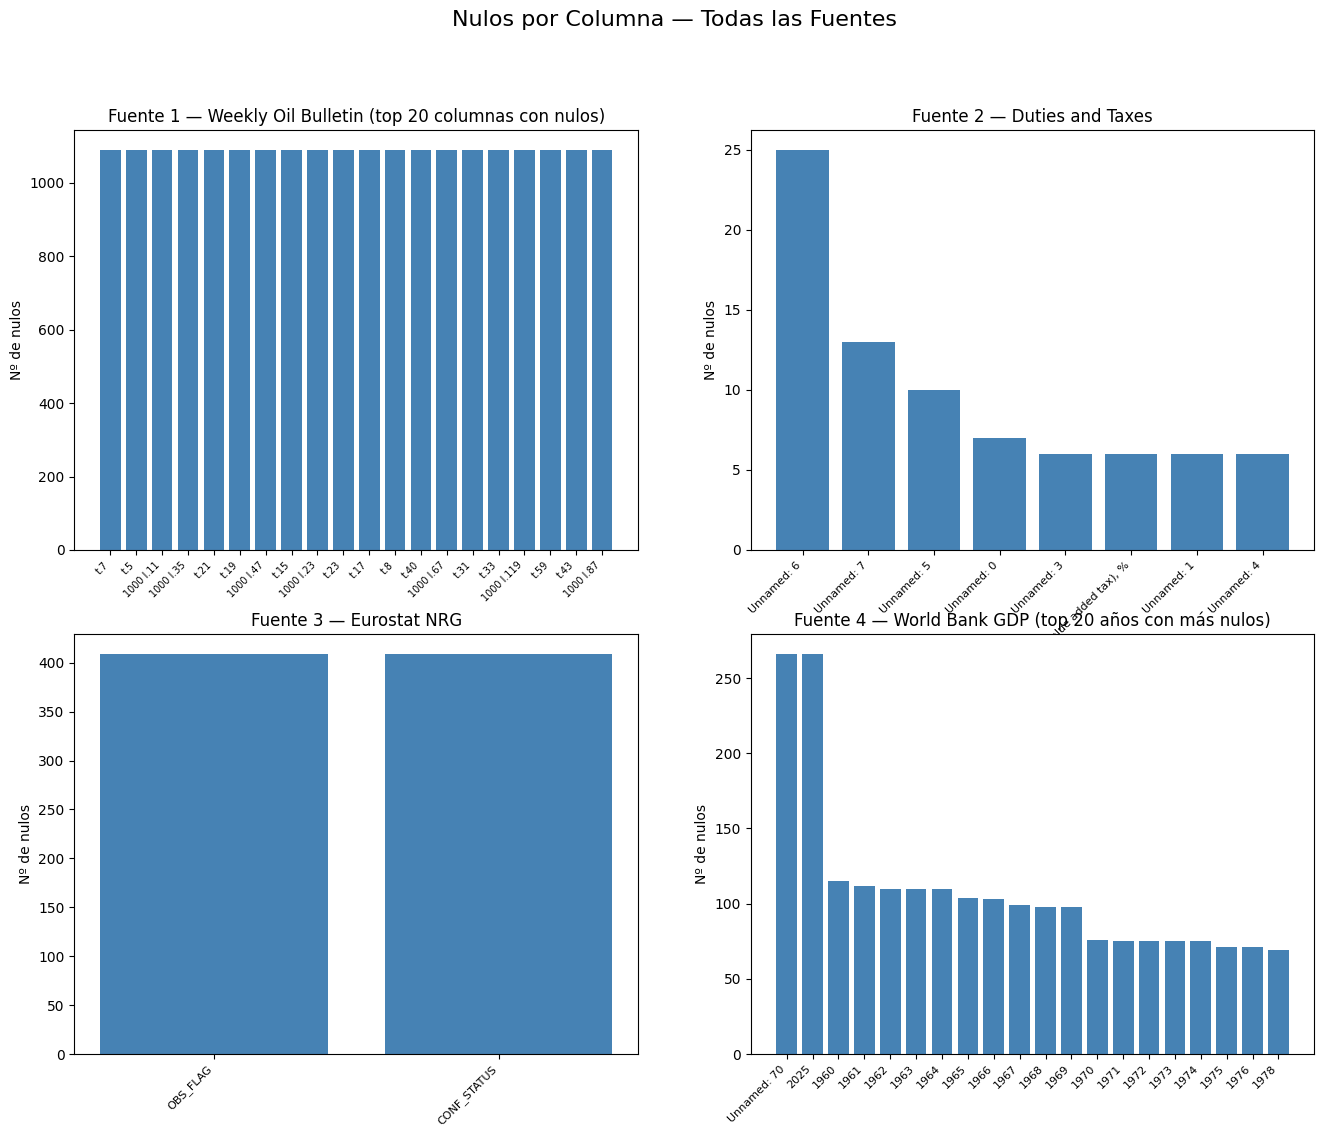

In [33]:
# GRÁFICO DE BARRAS DE NULOS POR FUENTE

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Nulos por Columna — Todas las Fuentes', fontsize=16)

# Fuente 1 - solo columnas que tienen nulos
nulos_f1 = df1.isnull().sum()
nulos_f1 = nulos_f1[nulos_f1 > 0].sort_values(ascending=False).head(20)
axes[0,0].bar(range(len(nulos_f1)), nulos_f1.values, color='steelblue')
axes[0,0].set_title('Fuente 1 — Weekly Oil Bulletin (top 20 columnas con nulos)')
axes[0,0].set_ylabel('Nº de nulos')
axes[0,0].set_xticks(range(len(nulos_f1)))
axes[0,0].set_xticklabels(nulos_f1.index, rotation=45, ha='right', fontsize=7)

# Fuente 2
nulos_f2 = df2.isnull().sum().sort_values(ascending=False)
axes[0,1].bar(range(len(nulos_f2)), nulos_f2.values, color='steelblue')
axes[0,1].set_title('Fuente 2 — Duties and Taxes')
axes[0,1].set_ylabel('Nº de nulos')
axes[0,1].set_xticks(range(len(nulos_f2)))
axes[0,1].set_xticklabels(nulos_f2.index, rotation=45, ha='right', fontsize=8)

# Fuente 3
nulos_f3 = df3.isnull().sum()
nulos_f3 = nulos_f3[nulos_f3 > 0].sort_values(ascending=False)
axes[1,0].bar(range(len(nulos_f3)), nulos_f3.values, color='steelblue')
axes[1,0].set_title('Fuente 3 — Eurostat NRG')
axes[1,0].set_ylabel('Nº de nulos')
axes[1,0].set_xticks(range(len(nulos_f3)))
axes[1,0].set_xticklabels(nulos_f3.index, rotation=45, ha='right', fontsize=8)

# Fuente 4
nulos_f4 = df4.isnull().sum().iloc[4:]
nulos_f4 = nulos_f4[nulos_f4 > 0].sort_values(ascending=False).head(20)
axes[1,1].bar(range(len(nulos_f4)), nulos_f4.values, color='steelblue')
axes[1,1].set_title('Fuente 4 — World Bank GDP (top 20 años con más nulos)')
axes[1,1].set_ylabel('Nº de nulos')
axes[1,1].set_xticks(range(len(nulos_f4)))
axes[1,1].set_xticklabels(nulos_f4.index, rotation=45, ha='right', fontsize=8)



In [34]:
#Guardamos los gráficos como imagen
plt.tight_layout()
plt.savefig('barras_nulos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado")

<Figure size 640x480 with 0 Axes>

Gráfico guardado


### Interpretación — Nulos por Fuente

- **Fuente 1 — Weekly Oil Bulletin:** Las columnas con más valores nulos son las de los tipos de combustible (fuel oil, heating oil). Esto no es un error, es simplemente que no todos los países de la UE registran semanalmente esta información.

- **Fuente 2 — Duties and Taxes:** La columna Unnamed: 6 tiene 25 valores vacíos, siendo la columna con más datos faltantes. Esto nos indica que este tipo de impuesto no se aplica en todos los períodos o países.

- **Fuente 3 — Eurostat:** Las columnas OBS_FLAG y CONF_STATUS están completamente vacías (409 nulos sobre 409 filas).

- **Fuente 4 — World Bank GDP:** Los años más antiguos (1960-1965) tienen más nulos ya que muchos países no tenían sistemas de medición del PIB en esa época. Los valores van disminuyendo a medida que nos acercamos a años más recientes.

## Funnel de Registros por Fuente
Número de registros originales de cada fuente antes de la transformación.

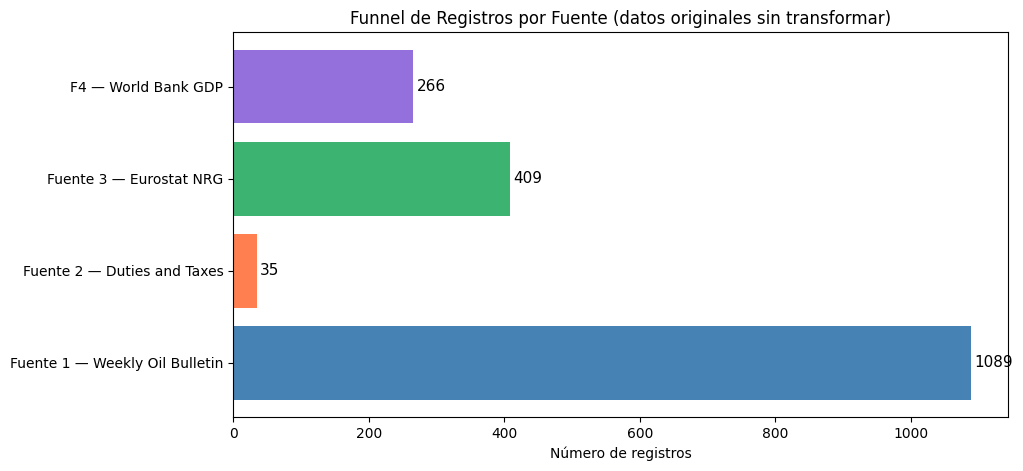

In [35]:
# FUNNEL DE REGISTROS POR FUENTE

fuentes = ['Fuente 1 — Weekly Oil Bulletin', 'Fuente 2 — Duties and Taxes',
           'Fuente 3 — Eurostat NRG', 'F4 — World Bank GDP']
registros = [df1.shape[0], df2.shape[0], df3.shape[0], df4.shape[0]]

plt.figure(figsize=(10, 5))
bars = plt.barh(fuentes, registros, color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
plt.xlabel('Número de registros')
plt.title('Funnel de Registros por Fuente (datos originales sin transformar)')

# Añadir etiquetas con el número exacto
for bar, valor in zip(bars, registros):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(valor), va='center', fontsize=11)


In [32]:
#Guardamos el gráfico como imagen
plt.tight_layout()
plt.savefig('funnel_registros.png', dpi=150, bbox_inches='tight')
plt.show()
print("Funnel guardado")

<Figure size 640x480 with 0 Axes>

Funnel guardado


### Interpretación — Funnel de Registros

En orden descendente del número de registros:

- **Fuente 1 — Weekly Oil Bulletin:** Tiene 1089 registros, es la fuente más grande con un registro por semana desde 1994 hasta 2026.

- **Fuente 3 — Eurostat:** Tiene 409 registros en formato largo, uno por cada país y año entre 2015 y 2024.

- **Fuente 4 — World Bank GDP:** Tiene 266 registros, uno por país, con columnas para cada año desde 1960 hasta 2024.

- **Fuente 2 — Duties and Taxes:** Solo tiene 35 registros, es la fuente más pequeña, ya que contiene los tipos de impuestos por país y estos cambian muy poco.

## Tabla Resumen de Calidad — Todas las Fuentes
Resumen de las métricas de calidad de las 4 fuentes antes de cualquier transformación.

In [45]:
# TABLA RESUMEN DE CALIDAD
tabla_calidad = pd.DataFrame([
    {
        'Fuente': 'Fuente 1 — Weekly Oil Bulletin',
        'Registros': 1089,
        'Variables': 226,
        'Nulos': df1.isnull().sum().sum(),
        'Blancos': 0,
        'Duplicados': df1.duplicated().sum(),
        'Outliers': 2782,
        'Observaciones': 'Formato ancho. Nombres de columnas poco descriptivos. Date como object.'
    },
    {
        'Fuente': 'Fuente 2 — Duties and Taxes',
        'Registros': 35,
        'Variables': 8,
        'Nulos': df2.isnull().sum().sum(),
        'Blancos': 0,
        'Duplicados': df2.duplicated().sum(),
        'Outliers': 0,
        'Observaciones': '3 hojas: VAT, Excise duties, Other Indirect Taxes. Valores numéricos como object.'
    },
    {
        'Fuente': 'Fuente 3 — Eurostat',
        'Registros': 409,
        'Variables': 10,
        'Nulos': df3.isnull().sum().sum(),
        'Blancos': 0,
        'Duplicados': df3.duplicated().sum(),
        'Outliers': 10,
        'Observaciones': 'Formato largo. OBS_FLAG y CONF_STATUS completamente vacías.'
    },
    {
        'Fuente': 'Fuente 4 — World Bank GDP',
        'Registros': 266,
        'Variables': 71,
        'Nulos': df4.isnull().sum().sum(),
        'Blancos': 0,
        'Duplicados': df4.duplicated().sum(),
        'Outliers': 1708,
        'Observaciones': 'Formato ancho. Unnamed:70 y 2025 vacías. Indicator Name/Code redundantes.'
    }
])

print(tabla_calidad.to_string(index=False))


                        Fuente  Registros  Variables  Nulos  Blancos  Duplicados  Outliers                                                                     Observaciones
Fuente 1 — Weekly Oil Bulletin       1089        226  58205        0           5      2782           Formato ancho. Nombres de columnas poco descriptivos. Date como object.
   Fuente 2 — Duties and Taxes         35          8     79        0           3         0 3 hojas: VAT, Excise duties, Other Indirect Taxes. Valores numéricos como object.
           Fuente 3 — Eurostat        409         10    818        0           0        10                       Formato largo. OBS_FLAG y CONF_STATUS completamente vacías.
     Fuente 4 — World Bank GDP        266         71   3261        0           0      1708         Formato ancho. Unnamed:70 y 2025 vacías. Indicator Name/Code redundantes.


In [46]:
# Guardar como CSV
tabla_calidad.to_csv('tabla_calidad_origenes.csv', index=False)
print("Tabla guardada como tabla_calidad_origenes.csv")

Tabla guardada como tabla_calidad_origenes.csv
